---
# NLI Analysis - UltraFine
> Laura Komorek
---

This notebook analyzes the performance of the fine-tuned distilled-RoBERTa model on the UltraFine test set.

We are focusing on:
- Error Analysis
- Robustness and Probing

---
## Imports

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import torch
import spacy
import random
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix

%matplotlib inline

---
## Load UltraFine

In [2]:
with open("ultra_test_predictions.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

print(df.columns)
df.head(2)

Index(['premise', 'hypothesis', 'gold_label', 'prediction'], dtype='object')


,premise,hypothesis,gold_label,prediction
0,"On late Monday night , 30th Nov 2009 , Banglad...",late Monday night is a size.,NOT ENTAILMENT,NOT ENTAILMENT
1,"On late Monday night , 30th Nov 2009 , Banglad...",late Monday night is a scientist.,NOT ENTAILMENT,NOT ENTAILMENT


---
## Label Distribution and Baselines

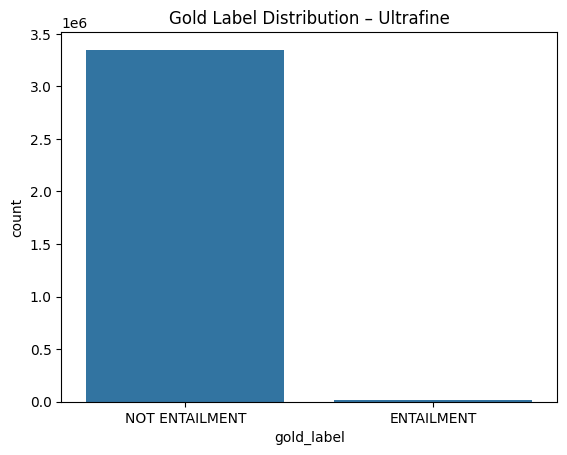

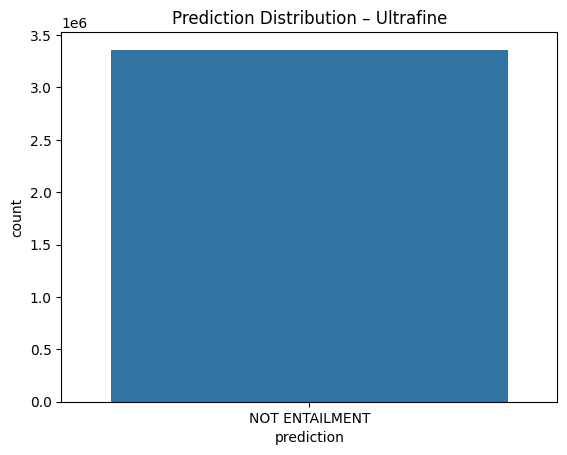

In [3]:
sns.countplot(x='gold_label', data=df)
plt.title('Gold Label Distribution – Ultrafine')
plt.show()

sns.countplot(x='prediction', data=df)
plt.title('Prediction Distribution – Ultrafine')
plt.show()

---
## Confusion Matrix

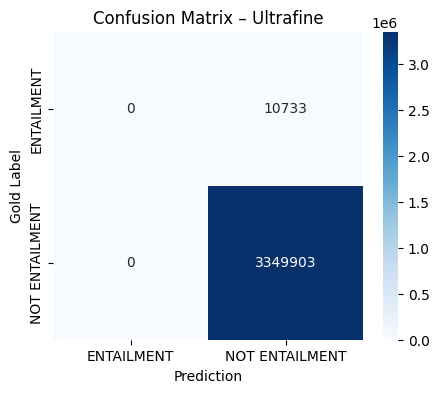

In [4]:
label_order = ["ENTAILMENT", "NOT ENTAILMENT"]

cm = confusion_matrix(df['gold_label'], df['prediction'], labels=label_order)
cm_df = pd.DataFrame(cm, index=label_order, columns=label_order)

plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Gold Label')
plt.xlabel('Prediction')
plt.title('Confusion Matrix – Ultrafine')
plt.show()

---
## Misclassification and Ambiguity Cases

In [5]:
fp = df[(df['gold_label']=='NOT ENTAILMENT') & (df['prediction']=='ENTAILMENT')]
print(f"Number of FP: {len(fp)}")
fp.head(5)

fn = df[(df['gold_label']=='ENTAILMENT') & (df['prediction']=='NOT ENTAILMENT')]
print(f"Number of FN: {len(fn)}")
fn.head(5)

Number of FP: 0
Number of FN: 10733


,premise,hypothesis,gold_label,prediction
120,"On late Monday night , 30th Nov 2009 , Banglad...",late Monday night is a day.,ENTAILMENT,NOT ENTAILMENT
234,"On late Monday night , 30th Nov 2009 , Banglad...",late Monday night is a date.,ENTAILMENT,NOT ENTAILMENT
312,"On late Monday night , 30th Nov 2009 , Banglad...",late Monday night is a time.,ENTAILMENT,NOT ENTAILMENT
1167,"On late Monday night , 30th Nov 2009 , Banglad...",late Monday night is a weekday.,ENTAILMENT,NOT ENTAILMENT
1765,"Leo W. Gerard , president of the steelworkers ...",joint events is a ceremony.,ENTAILMENT,NOT ENTAILMENT


---
## Robustness Test

We perform two complementary masking tests, such as:

1. Entity-Type-Masking: mask only certain entity types in hypothesis
2. Span/Clause Masking: mask full noun or verb phrases to test phrase-level roboustness

In [ ]:
nlp = spacy.load("en_core_web_sm", disable=["tagger", "lemmatizer"])

def mask_entities(text, entity_type="PERSON"):
    doc = nlp(text)
    masked_tokens = []
    for token in doc:
        if any(ent.label_ == entity_type for ent in doc.ents if token.idx >= ent.start_char and token.idx < ent.end_char):
            masked_tokens.append('[MASK]')
        else:
            masked_tokens.append(token.text)
    return ' '.join(masked_tokens)

def mask_phrases(text):
    doc = nlp(text)
    masked_tokens = []
    for chunk in doc.noun_chunks:
        for token in chunk:
            masked_tokens.append('[MASK]')
    masked_set = set(token.text for chunk in doc.noun_chunks for token in chunk)
    for token in doc:
        if token.text not in masked_set:
            masked_tokens.append(token.text)
    return ' '.join(masked_tokens)

df['hyp_mask_person'] = [mask_entities(hyp, "PERSON") for hyp in tqdm(df['hypothesis'], desc="Mask Person")]
df['hyp_mask_span']   = [mask_phrases(hyp) for hyp in tqdm(df['hypothesis'], desc="Mask Span")]

df.to_csv("ultra_masked.csv", index=False)

Mask Span: 100%|██████████| 200000/200000 [15:08<00:00, 220.02it/s]


---
## Load fine-tuned Model

In [8]:
model_path = r"C:\Users\Laura\Desktop\Uni\5. Semester (WS25-26)\Formale Semantik\Projekt\Analysis\UltraFine Experiments\ultra_predictions__none__premise_sep_hypothesis"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=False)

print("Loading model...")
model = AutoModelForSequenceClassification.from_pretrained(model_path)

print("Setting eval mode...")
model.eval()

print("Done!")

Loading tokenizer...
Loading model...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Setting eval mode...
Done!


---
## Run Masked Inputs on fine-tuned Model

In [ ]:
def predict_batch(premises, hypotheses, batch_size=32):
    preds = []
    for i in range(0, len(premises), batch_size):
        batch_p = premises[i:i+batch_size]
        batch_h = hypotheses[i:i+batch_size]
        inputs = tokenizer(batch_p, batch_h, padding=True, truncation=True, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            batch_preds = torch.argmax(logits, dim=1).tolist()
            preds.extend(batch_preds)
    return preds

# -- Predictions on Masked Inputs
pred_mask_person = predict_batch(df['premise'].tolist(), df['hyp_mask_person'].tolist())
pred_mask_span   = predict_batch(df['premise'].tolist(), df['hyp_mask_span'].tolist())

df['pred_mask_person'] = pred_mask_person
df['pred_mask_span']   = pred_mask_span

---
## Label Mapping

In [ ]:
label_map = {
    0: "NOT ENTAILMENT",
    1: "ENTAILMENT"
}

df['pred_mask_person_label'] = df['pred_mask_person'].map(label_map)
df['pred_mask_span_label'] = df['pred_mask_span'].map(label_map)

---
## Robustness Test and Error Analysis on Masked Results

In [ ]:
# -- Robustness Test

df['change_person'] = df['prediction'] != df['pred_mask_person_label']
df['change_span'] = df['prediction'] != df['pred_mask_span_label']

robustness_person = 1 - df['change_person'].mean()
robustness_span = 1 - df['change_span'].mean()

print(f"Robustness (Person Masking): {robustness_person:.2%}")
print(f"Robustness (Span Masking): {robustness_span:.2%}")

# -- Error Analysis

# False Positives (FP)
fp_person = df[
    (df['gold_label'] == 'NOT ENTAILMENT') &
    (df['pred_mask_person_label'] == 'ENTAILMENT')
]

fp_span = df[
    (df['gold_label'] == 'NOT ENTAILMENT') &
    (df['pred_mask_span_label'] == 'ENTAILMENT')
]

# False Negatives (FN)
fn_person = df[
    (df['gold_label'] == 'ENTAILMENT') &
    (df['pred_mask_person_label'] == 'NOT ENTAILMENT')
]

fn_span = df[
    (df['gold_label'] == 'ENTAILMENT') &
    (df['pred_mask_span_label'] == 'NOT ENTAILMENT')
]

print("\nError Analysis")
print("FP Person:", len(fp_person))
print("FN Person:", len(fn_person))
print("FP Span:", len(fp_span))
print("FN Span:", len(fn_span))

Robustness (Person Masking): 100.00%
Robustness (Span Masking): 100.00%

Error Analysis
FP Person: 0
FN Person: 637
FP Span: 0
FN Span: 637


---
## Interpretation

On the original UltraFine testset, the model already had a strong bias toward predicting "NOT ENTAILMENT", as seen by the 0 false positives and 10733 false negatives. This indicates that the model struggles to correctly identify positive entailment cases.

After applying the person and span masking, the robustness scores remain at 100%, meaning that the model's predictions don't change at all when key information is removed from the hypothesis.

The error analysis shwos that all errors are false negatives, while no false positives are observed, This confirms that the model consistently predicts "NOT ENTAILMENT", even if the input is modified.

The reduced number of false negatives in comparison to the full testset is not because the model improved, but rather because we only used a subset of 200k samples for this.

Overall however, the results indicate that the model is highly stable but not truly robust. Its predictions do not change under masking, but this is because it is already biased towards negative predictions in the first place. As a result, the model fails to dectect entailment regargless of whether the important tokens are present or masked.
